# 🟢 PROJECT · Easy · Mall Segments via Dendrogram

> **MLCourse · Machine Learning · unsupervised**

### What you'll learn
1. Produce the mall-customer segmentation with HIERARCHICAL clustering and
   compare its story to the K-Means module's five segments
2. Cut a ward tree at k=5 and build the same marketing profile table
3. Decide when hierarchy adds value over flat K-Means

**Business question:** *same as before - which income×spend audiences exist?
- but this time we want to see ALL granularities at once so the CMO can
argue about 3 vs 5 campaigns from one picture.*

### Setup


In [ ]:
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

from pathlib import Path
import urllib.request


def get_data(fname: str, url: str) -> Path:
    """Walk up to course root '02_machine_learning'; download-once helper."""
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "02_machine_learning").is_dir():
            fpath = base / "02_machine_learning" / "data" / fname
            break
    else:
        raise RuntimeError("course data folder not found")
    if not fpath.exists():
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/"
            "master/Machine%20Learning%20A-Z%20Template%20Folder/"
            "Part%204%20-%20Clustering/Section%2024%20-%20K-Means%20Clustering/"
            "Mall_Customers.csv", fpath)
    return fpath

MALL_URL = ("https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/"
            "master/Machine%20Learning%20A-Z%20Template%20Folder/"
            "Part%204%20-%20Clustering/Section%2024%20-%20K-Means%20Clustering/"
            "Mall_Customers.csv")

mall_path = get_data("mall_customers.csv", MALL_URL)
if not mall_path.exists():                       # safety on first-ever run
    urllib.request.urlretrieve(MALL_URL, mall_path)


### 1. Load & EDA (compact - full tour lives in the K-Means project)


In [2]:
mall = pd.read_csv(mall_path)
print(mall.shape, "| missing:", int(mall.isna().sum().sum()))
mall[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].describe().round(1)

(200, 5) | missing: 0


,Age,Annual Income (k$),Spending Score (1-100)
count,200.0,200.0,200.0
mean,38.8,60.6,50.2
std,14.0,26.3,25.8
min,18.0,15.0,1.0
25%,28.8,41.5,34.8
50%,36.0,61.5,50.0
75%,49.0,78.0,73.0
max,70.0,137.0,99.0


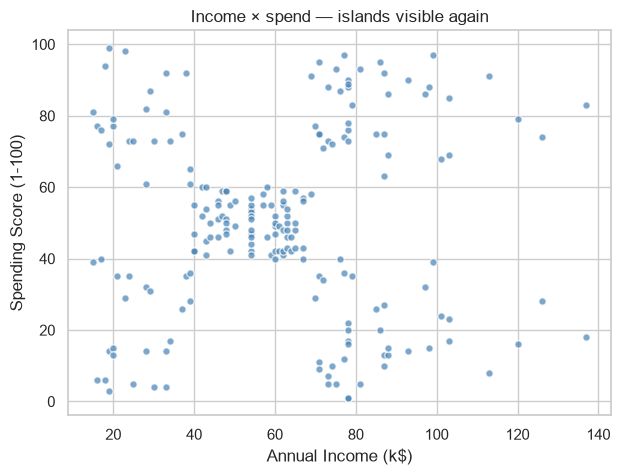

In [3]:
plt.figure(figsize=(7, 5))                       # the two clustering axes
plt.scatter(mall["Annual Income (k$)"], mall["Spending Score (1-100)"],
            s=28, alpha=0.7, color="steelblue", edgecolor="white")
plt.xlabel("Annual Income (k$)"); plt.ylabel("Spending Score (1-100)")
plt.title("Income × spend - islands visible again")
plt.show()

### 2. Processing - select features + scale (mandatory for distances)


In [4]:
feat_cols = ["Annual Income (k$)", "Spending Score (1-100)"]
scaler = StandardScaler()
X = scaler.fit_transform(mall[feat_cols])         # comparable axes

### 3. Modeling - ward tree, then cut at k=5


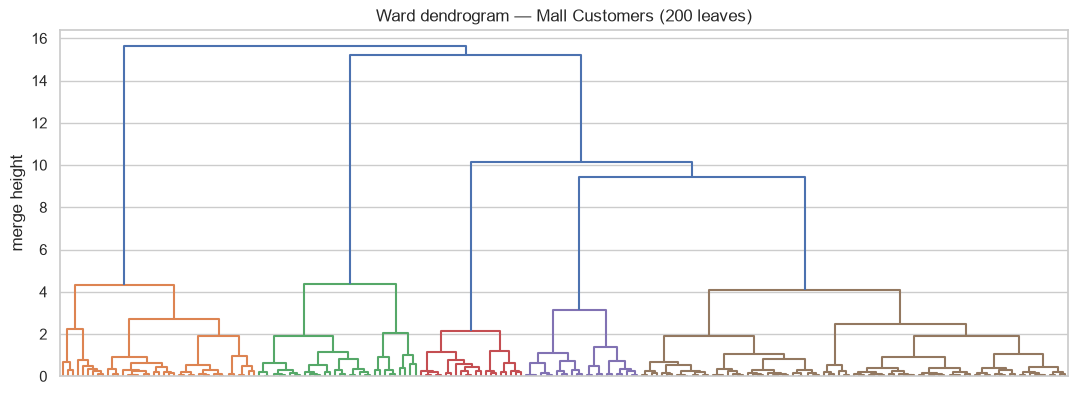

sizes: {0: 32, 1: 39, 2: 85, 3: 21, 4: 23}
silhouette: 0.554


In [5]:
Z = linkage(X, method="ward")                     # merge table (199 merges)

fig, ax = plt.subplots(figsize=(13, 4.5))
dendrogram(Z, no_labels=True, color_threshold=8, ax=ax)   # colour below threshold
ax.set_title("Ward dendrogram - Mall Customers (200 leaves)")
ax.set_ylabel("merge height"); plt.show()

agg5 = AgglomerativeClustering(n_clusters=5, linkage="ward").fit(X)
mall["cluster"] = agg5.labels_
print("sizes:", mall["cluster"].value_counts().sort_index().to_dict())
print(f"silhouette: {silhouette_score(X, agg5.labels_):.3f}")

### 4. Segment profiles - same table style as the K-Means project


In [6]:
profile = (mall.assign(cluster=mall["cluster"])
               .groupby("cluster")
               .agg(size=("cluster", "size"),
                    age_mean=("Age", "mean"),
                    income_mean=("Annual Income (k$)", "mean"),
                    spend_mean=("Spending Score (1-100)", "mean"))
               .round(1))

def name_seg(r):                                  # identical naming logic as before
    inc = ("high-income" if r.income_mean >= 70 else
           "mid-income" if r.income_mean >= 40 else "low-income")
    spd = ("big-spender" if r.spend_mean >= 60 else
           "moderate" if r.spend_mean >= 40 else "careful")
    return f"{inc} {spd}"

profile["segment"] = profile.apply(name_seg, axis=1)
profile.sort_values("spend_mean", ascending=False)

,size,age_mean,income_mean,spend_mean,segment
cluster,,,,,
1,39,32.7,86.5,82.1,high-income big-spender
3,21,25.3,25.1,80.0,low-income big-spender
2,85,42.5,55.8,49.1,mid-income moderate
4,23,45.2,26.3,20.9,low-income careful
0,32,41.0,89.4,15.6,high-income careful


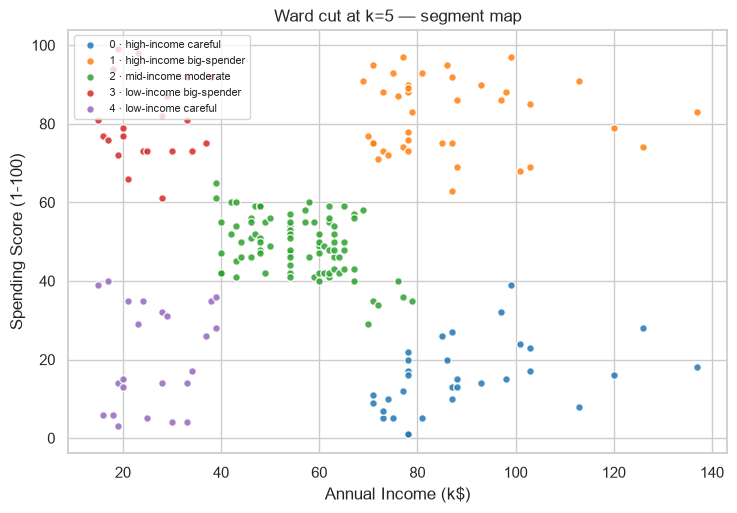

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))        # visual check of the cut
pal = sns.color_palette("tab10", 5)
for c in sorted(profile.index):
    sub = mall[mall.cluster == c]
    ax.scatter(sub["Annual Income (k$)"], sub["Spending Score (1-100)"],
               s=30, alpha=0.85, color=pal[c], edgecolor="white",
               label=f"{c} · {profile.loc[c,'segment']}")
ax.set_xlabel("Annual Income (k$)"); ax.set_ylabel("Spending Score (1-100)")
ax.set_title("Ward cut at k=5 - segment map")
ax.legend(fontsize=8, loc="upper left"); plt.show()

### Findings

- The ward tree recovers THE SAME five-island story K-Means told: high-income
  big-spenders, high-income careful, low-income big-spenders, low-income
  careful, mid-income moderates. Two very different algorithms agreeing is a
  robustness signal worth reporting.
- Bonus of hierarchy: the dendrogram ALSO offers coarser cuts (3 clusters =
  spenders / careful / middle) for executives who want fewer campaigns -
  one fit serves many granularities.
- Silhouette (~0.55 raw-unit scale) matches K-Means' ballpark; neither
  algorithm dominates on this blob-shaped toy geometry.

⚠️ Limitations: two-feature dataset flatters both methods; ward has no
`.predict()` for future customers (wrap nearest-centroid if CRM needs it);
and cutting at exactly 5 was chosen to mirror the K-Means story, not derived
from this tree alone.